# Web Scraping Project - CodeAlpha Task 1
## Objective: Extract product data from an e-commerce website for analysis

This notebook demonstrates professional web scraping techniques using Python.
We will scrape product information, handle pagination, and export clean data for analysis.

In [1]:
# Install necessary libraries (run once)
!pip install beautifulsoup4 requests pandas lxml html5lib

# For dynamic content (uncomment if needed)
# !pip install selenium webdriver-manager

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Install necessary libraries (run once)
!pip install beautifulsoup4 requests pandas lxml html5lib

# For dynamic content (uncomment if needed)
# !pip install selenium webdriver-manager

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Web scraping
import requests
from bs4 import BeautifulSoup

# Time handling (for politeness)
import time
import random

# File handling
import csv
from datetime import datetime

# Display settings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Configuration
BASE_URL = "http://books.toscrape.com/catalogue/page-{}.html"
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}
DELAY = random.uniform(2, 5)  # Random delay to be respectful

print(f"Configuration complete. Base URL: {BASE_URL}")

Configuration complete. Base URL: http://books.toscrape.com/catalogue/page-{}.html


In [5]:
# Test with first page
test_url = BASE_URL.format(1)
response = requests.get(test_url, headers=HEADERS)

if response.status_code == 200:
    print(f"✓ Successfully connected to {test_url}")
    soup = BeautifulSoup(response.content, 'html.parser')
    
    # Preview the HTML structure
    print("\nPage title:", soup.title.string)
    print("\nFirst few product articles:")
    articles = soup.find_all('article', class_='product_pod')[:2]
    for article in articles:
        print(article.prettify()[:500])  # Preview first 500 chars
else:
    print(f"✗ Failed to connect. Status code: {response.status_code}")

✓ Successfully connected to http://books.toscrape.com/catalogue/page-1.html

Page title: 
    All products | Books to Scrape - Sandbox


First few product articles:
<article class="product_pod">
 <div class="image_container">
  <a href="a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="../media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="a-light-in-the-attic_1000/index.html" title="A
<article class="product_pod">
 <div class="image_container">
  <a href="tipping-the-velvet_999/index.html">
   <img alt="Tipping the Velvet" class="thumbnail" src="../media/cache/26/0c/260c6ae16bce31c8f8c95daddd9f4a1c.jpg"/>
  </a>
 </div>
 <p class="star-rating One">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <

In [6]:
def fetch_page(url):
    """
    Fetch a webpage with error handling and respect for robots.txt
    """
    try:
        response = requests.get(url, headers=HEADERS, timeout=10)
        response.raise_for_status()
        return BeautifulSoup(response.content, 'html.parser')
    except requests.exceptions.RequestException as e:
        print(f"Error fetching {url}: {e}")
        return None

def extract_book_data(book_article):
    """
    Extract structured data from a single book article
    Returns a dictionary with cleaned data
    """
    # Title extraction
    title_tag = book_article.find('h3').find('a')
    title = title_tag.get('title', 'N/A') if title_tag else 'N/A'
    
    # Price extraction (clean currency symbol)
    price_tag = book_article.find('p', class_='price_color')
    price = price_tag.text.strip() if price_tag else 'N/A'
    price = price.replace('£', '').replace('Â', '')  # Clean currency
    
    # Availability
    avail_tag = book_article.find('p', class_='instock availability')
    availability = avail_tag.text.strip() if avail_tag else 'N/A'
    
    # Rating (convert to numeric)
    rating_tag = book_article.find('p', class_='star-rating')
    rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
    rating = 'N/A'
    if rating_tag:
        for class_name in rating_tag.get('class', []):
            if class_name in rating_map:
                rating = rating_map[class_name]
                break
    
    # URL
    relative_url = title_tag.get('href', '') if title_tag else ''
    full_url = f"http://books.toscrape.com/catalogue/{relative_url}"
    
    return {
        'title': title,
        'price': float(price) if price != 'N/A' else None,
        'availability': availability,
        'rating': rating,
        'url': full_url,
        'scraped_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

print("Functions defined successfully!")

Functions defined successfully!


In [7]:
# Initialize empty list to store all books
all_books = []
page_num = 1
max_pages = 3  # Limit for demo; remove for full scrape

print("Starting web scraping...")
print("-" * 50)

while True:
    print(f"Scraping page {page_num}...")
    
    # Fetch the page
    url = BASE_URL.format(page_num)
    soup = fetch_page(url)
    
    if not soup:
        print(f"Failed to load page {page_num}. Stopping.")
        break
    
    # Find all book articles
    books = soup.find_all('article', class_='product_pod')
    
    if not books:
        print(f"No books found on page {page_num}. Stopping.")
        break
    
    # Extract data from each book
    for book in books:
        book_data = extract_book_data(book)
        all_books.append(book_data)
    
    print(f"✓ Page {page_num}: Extracted {len(books)} books. Total: {len(all_books)}")
    
    # Check for next page
    next_button = soup.find('li', class_='next')
    if not next_button or page_num >= max_pages:
        break
    
    # Polite delay before next request
    delay = random.uniform(2, 4)
    print(f"Waiting {delay:.1f} seconds before next request...")
    time.sleep(delay)
    
    page_num += 1

print("-" * 50)
print(f"Scraping complete! Total books collected: {len(all_books)}")

Starting web scraping...
--------------------------------------------------
Scraping page 1...
✓ Page 1: Extracted 20 books. Total: 20
Waiting 3.9 seconds before next request...
Scraping page 2...
✓ Page 2: Extracted 20 books. Total: 40
Waiting 2.0 seconds before next request...
Scraping page 3...
✓ Page 3: Extracted 20 books. Total: 60
--------------------------------------------------
Scraping complete! Total books collected: 60


In [8]:
# Convert to DataFrame
df_books = pd.DataFrame(all_books)

# Display basic info
print("Dataset Info:")
print(f"Shape: {df_books.shape}")
print(f"Columns: {df_books.columns.tolist()}")
print("\nFirst 5 rows:")
df_books.head()

Dataset Info:
Shape: (60, 6)
Columns: ['title', 'price', 'availability', 'rating', 'url', 'scraped_date']

First 5 rows:


,title,price,availability,rating,url,scraped_date
0,A Light in the Attic,51.77,In stock,3,http://books.toscrape.com/catalogue/a-light-in...,2026-03-10 00:02:26
1,Tipping the Velvet,53.74,In stock,1,http://books.toscrape.com/catalogue/tipping-th...,2026-03-10 00:02:26
2,Soumission,50.10,In stock,1,http://books.toscrape.com/catalogue/soumission...,2026-03-10 00:02:26
3,Sharp Objects,47.82,In stock,4,http://books.toscrape.com/catalogue/sharp-obje...,2026-03-10 00:02:26
4,Sapiens: A Brief History of Humankind,54.23,In stock,5,http://books.toscrape.com/catalogue/sapiens-a-...,2026-03-10 00:02:26


In [9]:
# Data quality checks
print("Data Quality Report:")
print("-" * 30)

# Check missing values
missing = df_books.isnull().sum()
print("\nMissing Values:")
print(missing[missing > 0] if any(missing > 0) else "No missing values found!")

# Check duplicates
duplicates = df_books.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Summary statistics for numeric columns
print("\nSummary Statistics:")
print(df_books.describe())

# Value counts for categorical data
print("\nRating Distribution:")
print(df_books['rating'].value_counts().sort_index())

print("\nPrice Range:")
print(f"Min: £{df_books['price'].min():.2f}")
print(f"Max: £{df_books['price'].max():.2f}")
print(f"Mean: £{df_books['price'].mean():.2f}")
print(f"Median: £{df_books['price'].median():.2f}")

Data Quality Report:
------------------------------

Missing Values:
No missing values found!

Duplicate rows: 0

Summary Statistics:
           price     rating
count  60.000000  60.000000
mean   35.002667   3.000000
std    14.553082   1.507046
min    12.840000   1.000000
25%    22.040000   1.750000
50%    33.485000   3.000000
75%    50.142500   4.000000
max    57.310000   5.000000

Rating Distribution:
rating
1    15
2     8
3    13
4    10
5    14
Name: count, dtype: int64

Price Range:
Min: £12.84
Max: £57.31
Mean: £35.00
Median: £33.48


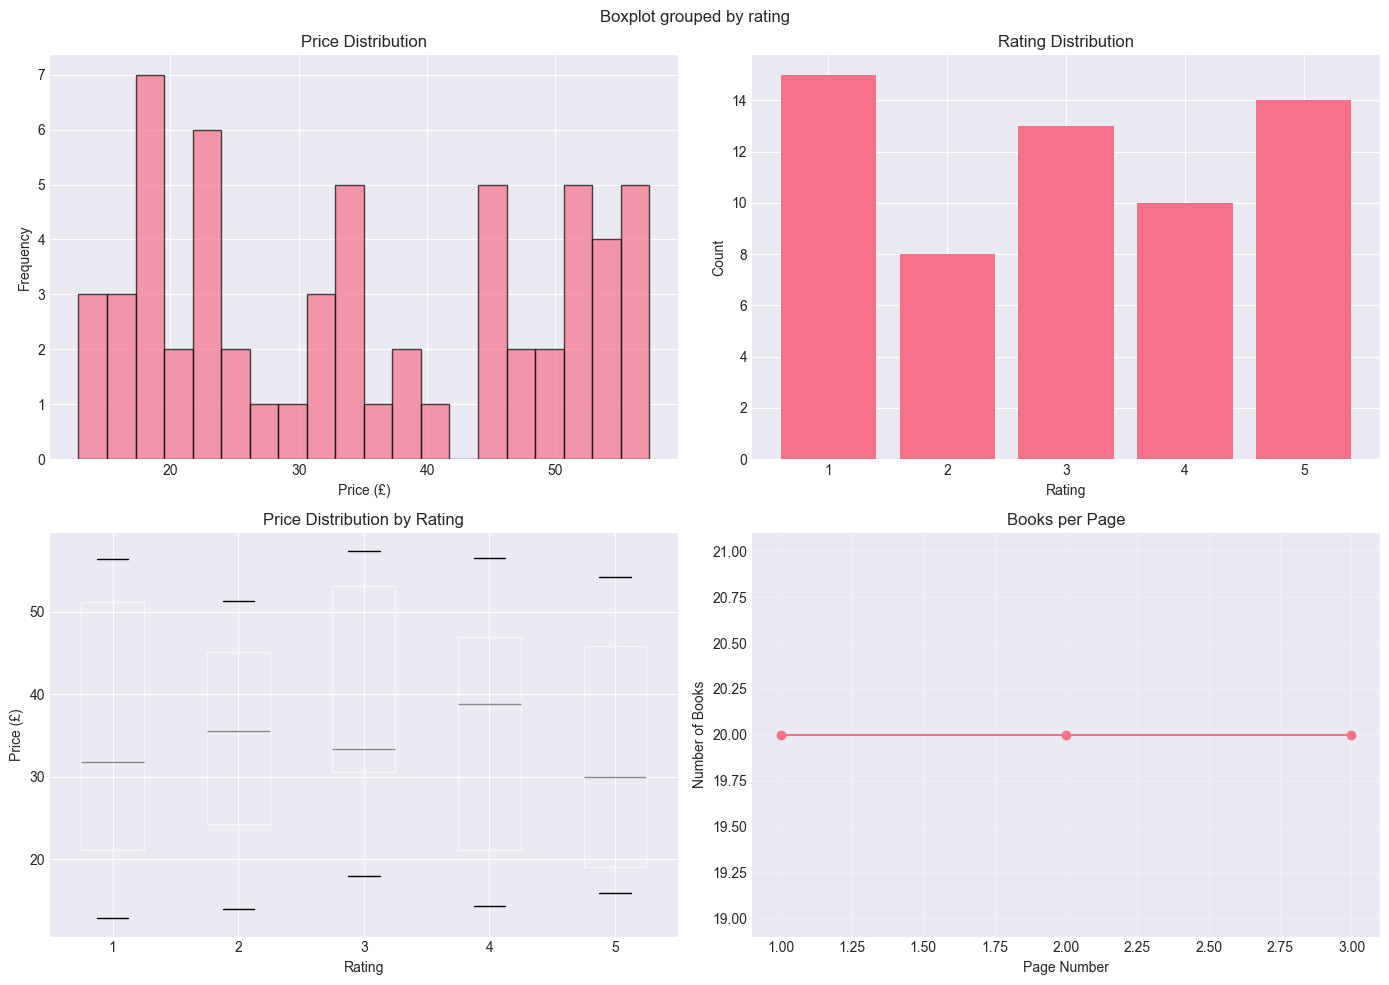

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Books Scraping - Data Overview', fontsize=16, fontweight='bold')

# Price distribution
axes[0, 0].hist(df_books['price'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price (£)')
axes[0, 0].set_ylabel('Frequency')

# Rating distribution
rating_counts = df_books['rating'].value_counts().sort_index()
axes[0, 1].bar(rating_counts.index.astype(str), rating_counts.values)
axes[0, 1].set_title('Rating Distribution')
axes[0, 1].set_xlabel('Rating')
axes[0, 1].set_ylabel('Count')

# Price by rating
df_books.boxplot(column='price', by='rating', ax=axes[1, 0])
axes[1, 0].set_title('Price Distribution by Rating')
axes[1, 0].set_xlabel('Rating')
axes[1, 0].set_ylabel('Price (£)')

# Books per page
books_per_page = df_books.groupby(df_books.index // 20).size()  # Assuming 20 per page
axes[1, 1].plot(books_per_page.index + 1, books_per_page.values, marker='o')
axes[1, 1].set_title('Books per Page')
axes[1, 1].set_xlabel('Page Number')
axes[1, 1].set_ylabel('Number of Books')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Create timestamp for filename
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f'books_scraped_{timestamp}'

# Export to CSV (Excel-friendly)
csv_path = f'{filename}.csv'
df_books.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"✓ CSV saved: {csv_path}")

# Export to Excel with formatting
excel_path = f'{filename}.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_books.to_excel(writer, sheet_name='Books Data', index=False)
    
    # Auto-adjust column widths
    worksheet = writer.sheets['Books Data']
    for column in worksheet.columns:
        max_length = 0
        column_letter = column[0].column_letter
        for cell in column:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        adjusted_width = min(max_length + 2, 50)
        worksheet.column_dimensions[column_letter].width = adjusted_width

print(f"✓ Excel saved: {excel_path}")

# Export to JSON (for APIs)
json_path = f'{filename}.json'
df_books.to_json(json_path, orient='records', indent=2)
print(f"✓ JSON saved: {json_path}")

# Summary report
report_path = f'{filename}_summary.txt'
with open(report_path, 'w') as f:
    f.write("WEB SCRAPING PROJECT SUMMARY\n")
    f.write("=" * 40 + "\n")
    f.write(f"Project: CodeAlpha Task 1 - Web Scraping\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Source: http://books.toscrape.com\n")
    f.write(f"Pages scraped: {page_num}\n")
    f.write(f"Total records: {len(df_books)}\n")
    f.write(f"Price range: £{df_books['price'].min():.2f} - £{df_books['price'].max():.2f}\n")
    f.write(f"Average price: £{df_books['price'].mean():.2f}\n")
    f.write(f"Most common rating: {df_books['rating'].mode()[0]}\n")
    
print(f"✓ Summary saved: {report_path}")

✓ CSV saved: books_scraped_20260310_000242.csv
✓ Excel saved: books_scraped_20260310_000242.xlsx
✓ JSON saved: books_scraped_20260310_000242.json
✓ Summary saved: books_scraped_20260310_000242_summary.txt
